# Decision Trees

**Course:** CMOR 438 - Machine Learning
**Dataset:** GuitarSet (audio_hex_cln, string 0, 5 tracks)
**Task:** Given 18 audio features extracted from a from a 46 ms frame, predict whether a guitar note is being played (*voiced*) or not (*silent*).

Before we get into this, let's first explain the basics of a decision tree. 
---

## **1. Intuition**

A decision tree is a supervised learning algorithm, used for both classification and regression. In this case, we'll be sticking with a decision tree, because we're only working with a GuitarSet that classifies based on binary variables (Voiced/Silent). A regession tree can classify based on gradients.

The tree functions through seeking **recursive greedy splitting**, which means that we sort nodes on features that produce the **most** delineated segments. In our case, this would mean the most accurate split between Voiced/Silent
---

## **2: Splitting Methods **

# Gini Impurity: Measuring Node Purity

Gini Impurity is a metric used by Decision Trees to evaluate the quality of a split. It measures the probability of a randomly chosen element being incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

## a. The Mathematical Formula

For a dataset with $J$ classes, the Gini Impurity ($G$) is defined as:

$$G = 1 - \sum_{i=1}^{J} P_i^2$$

Where:
* $P_i$ is the probability (ratio) of samples belonging to class $i$ at that specific node.
* **Range:** The value ranges from $0$ (Complete Purity) to $0.5$ (Maximum Impurity for a 2-class problem).


---

## b. Step-by-Step Example

A preliminary example with our voiced/silent classes: (Class 0: **Silent**, Class 1: **Voiced**).

### Scenario: A "Messy" Node
Suppose a node contains **10 audio frames**: 8 are Voiced and 2 are Silent.

1. **Calculate Probabilities ($P_i$):**
   - $P(\text{Voiced}) = 8/10 = 0.8$
   - $P(\text{Silent}) = 2/10 = 0.2$

2. **Square the Probabilities:**
   - $0.8^2 = 0.64$
   - $0.2^2 = 0.04$

3. **Subtract from 1:**
   - $G = 1 - (0.64 + 0.04)$
   - $G = 1 - 0.68 = \mathbf{0.32}$

---

## c. How Decision Trees Use Gini

The algorithm iterates through every feature (e.g., RMS, Spectral Centroid) and every possible threshold to find the "Best Split." The best split is the one that results in the highest **Information Gain**, calculated as:

$$Gain = G_{\text{parent}} - \sum (w_i \times G_{\text{child}_i})$$

Where $w_i$ is the weight (percentage of total samples) that ended up in that specific child node. The tree grows by choosing splits that decrease impurity the most.
---

## **3. How a Decision Tree is Built (Top-Down Induction)**

1.  **Calculate Impurity:** Measure the Gini Impurity or Entropy of the current dataset.
2.  **Evaluate Potential Splits:** For every feature (e.g., RMS, Spectral Centroid) and every possible value of that feature, temporarily split the data and calculate the resulting Gini Impurity of the children.
3.  **Choose the Best Split:** Select the feature and threshold that provide the highest **Information Gain** (the largest reduction in impurity).
4.  **Recurse:** Repeat the process for each child node until a "Stopping Criterion" is met.

---



Now, let's import our datasets, and test on the diabetes.csv for accurracy.

In [ ]:
import sys
from pathlib import Path

def _find_repo_root(marker: str = "pyproject.toml") -> Path | None:
    for candidate in [Path().resolve(), *Path().resolve().parents]:
        if (candidate / marker).exists():
            return candidate
    return None

REPO_ROOT = _find_repo_root()
if REPO_ROOT is not None:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    print(f"Repo root: {REPO_ROOT}")
else:
    try:
        import rice_Ml as _check
        print(f"rice_Ml installed at: {Path(_check.__file__).resolve()}")
    except ImportError:
        raise ImportError(
            "rice_Ml not found. Install with:\n"
            "    pip install -e /path/to/cmor438-s2026-final-project"
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from rice_Ml.datasets import load_guitarset, FEATURE_COLS
from rice_Ml.supervised_ml.DecisionTree.decision_tree import DecisionTree
from rice_Ml.metrics import accuracy
from rice_Ml.model_selection.split import train_test_split

SEED = 42

FEATURE_NAMES = [
    "RMS", "ZCR", "Centroid", "Bandwidth", "Rolloff",
    *[f"MFCC {i}" for i in range(1, 14)],
]

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Imports OK")


Repo root: C:\Users\joshh\hongtao'sfiles\School\Year3 S2\INDE577ML\INDE577 Final Project\cmor438-s2026-final-project
Imports OK


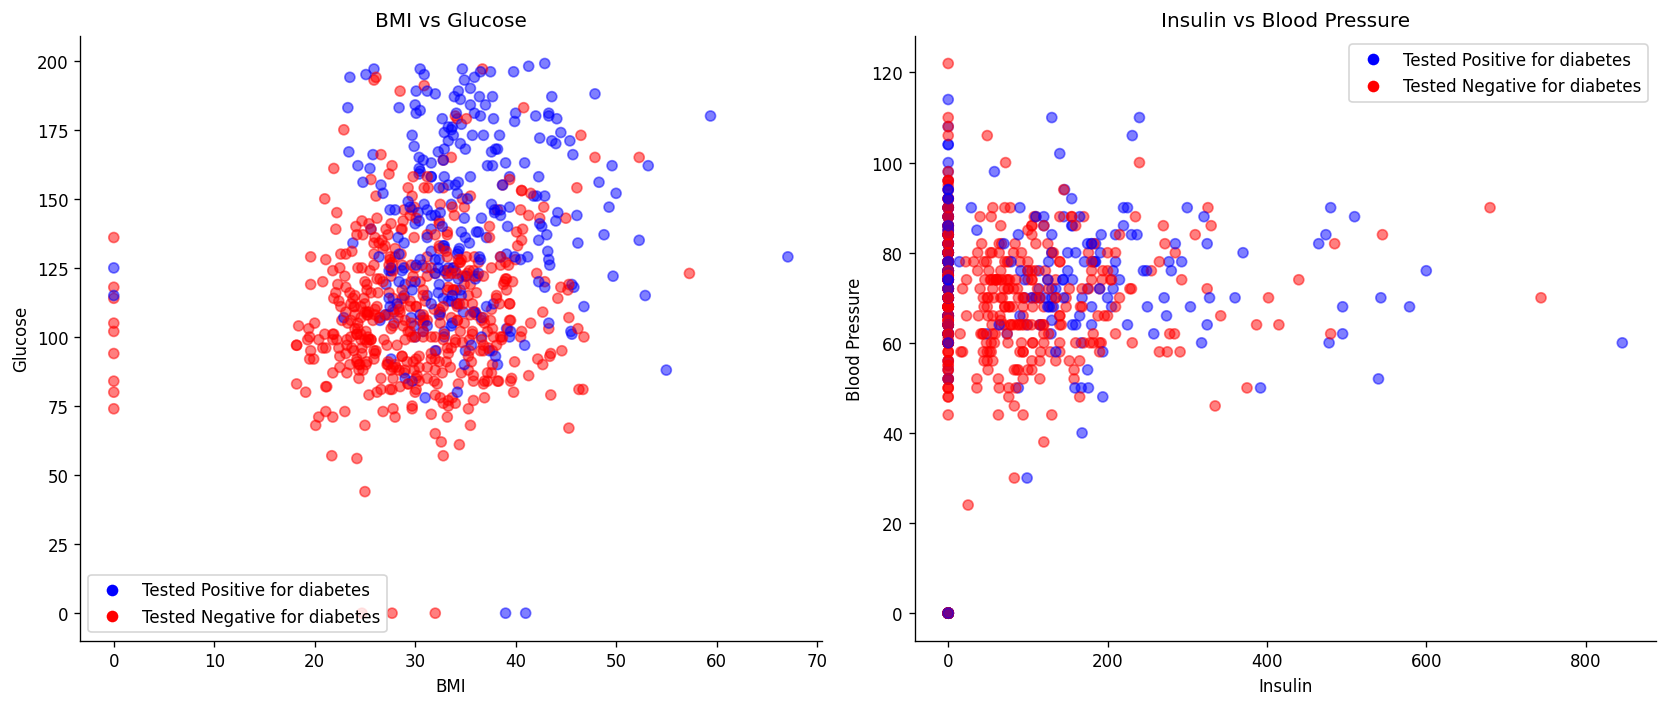

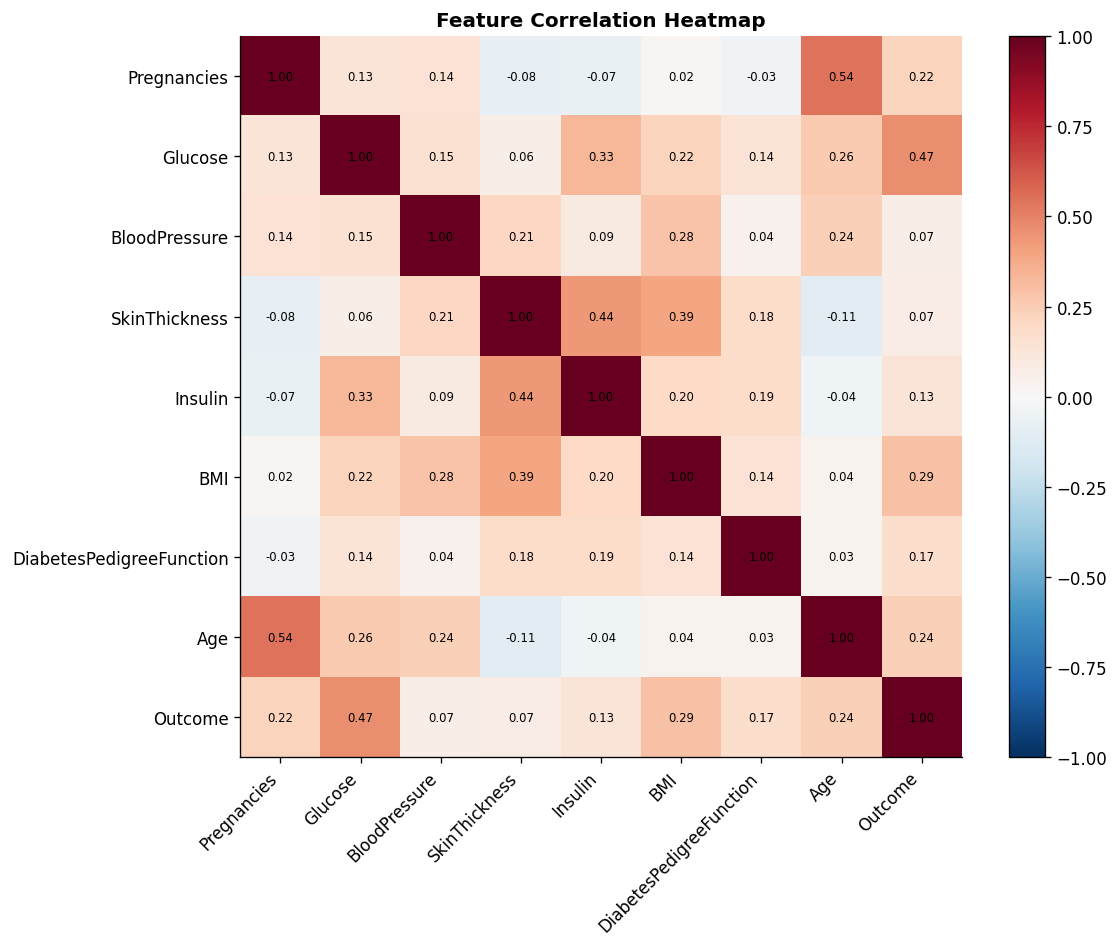

In [10]:
# import diabetes.csv and make plots
data = pd.read_csv("diabetes.csv")
colors = data["Outcome"].map({1: "blue", 0: "red"})
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Tested Positive for diabetes'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',  markersize=8, label='Tested Negative for diabetes'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#line graph of BMI vs Glucose, with Outcomes colored blue for 1 and red for 0
ax1.scatter(data["BMI"], data["Glucose"], c=colors, alpha=0.5)
ax1.set_xlabel("BMI"); ax1.set_ylabel("Glucose"); ax1.set_title("BMI vs Glucose")
ax1.legend(handles=legend_handles)

#line graph of Insulin vs Blood Pressure, with Outcomes colored blue for 1 and red for 0

ax2.scatter(data["Insulin"], data["BloodPressure"], c=colors, alpha=0.5)
ax2.set_xlabel("Insulin"); ax2.set_ylabel("Blood Pressure"); ax2.set_title("Insulin vs Blood Pressure")
ax2.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
corr = data.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Feature Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()



From this Feature Correlation Heatmap, we can see that "Glucose" has the strongest positive correlation with "Outcome" (0.47), followed by "BMI" (0.32) and "Age" (0.24). "Pregnancies" and "Insulin" also show some positive correlation with "Outcome", while "SkinThickness" and "BloodPressure" have weaker correlations. This suggests that "Glucose", "BMI", and "Age" may be the most important features for predicting diabetes in this dataset. Now, let's run our analysis!

In [11]:
from rice_Ml.supervised_ml.DecisionTree.decision_tree import DecisionTree
from rice_Ml.model_selection.split import train_test_split
from rice_Ml.metrics import accuracy

X = data.drop(columns=["Outcome"]).values
y = data["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

tree = DecisionTree(max_depth=4, criterion="gini")
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {accuracy(y_test, y_pred):.3f}")


Train accuracy: 0.814
Test accuracy:  0.734


Our model is Train accuracy: 0.814
Test accuracy:  0.734

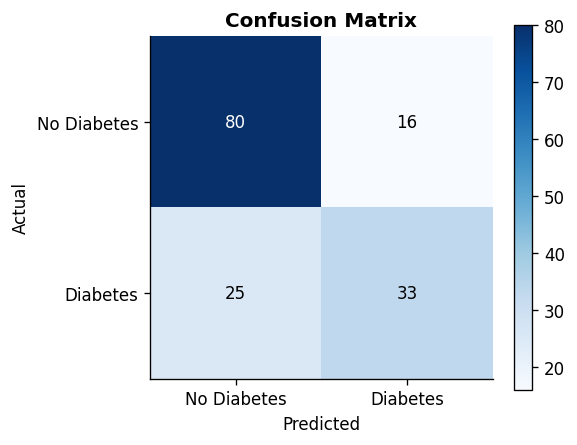

In [14]:
cm = np.array([
    [(( y_test==0) & (y_pred==0)).sum(), ((y_test==0) & (y_pred==1)).sum()],
    [((y_test==1) & (y_pred==0)).sum(),  ((y_test==1) & (y_pred==1)).sum()],
])

class_names = ["No Diabetes", "Diabetes"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(2)); ax.set_xticklabels(class_names)
ax.set_yticks(range(2)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix", fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()


### Let's make a simpler tree and see how it fares

Our DT   — train: 0.814  test: 0.734
Sklearn  — train: 0.814  test: 0.734


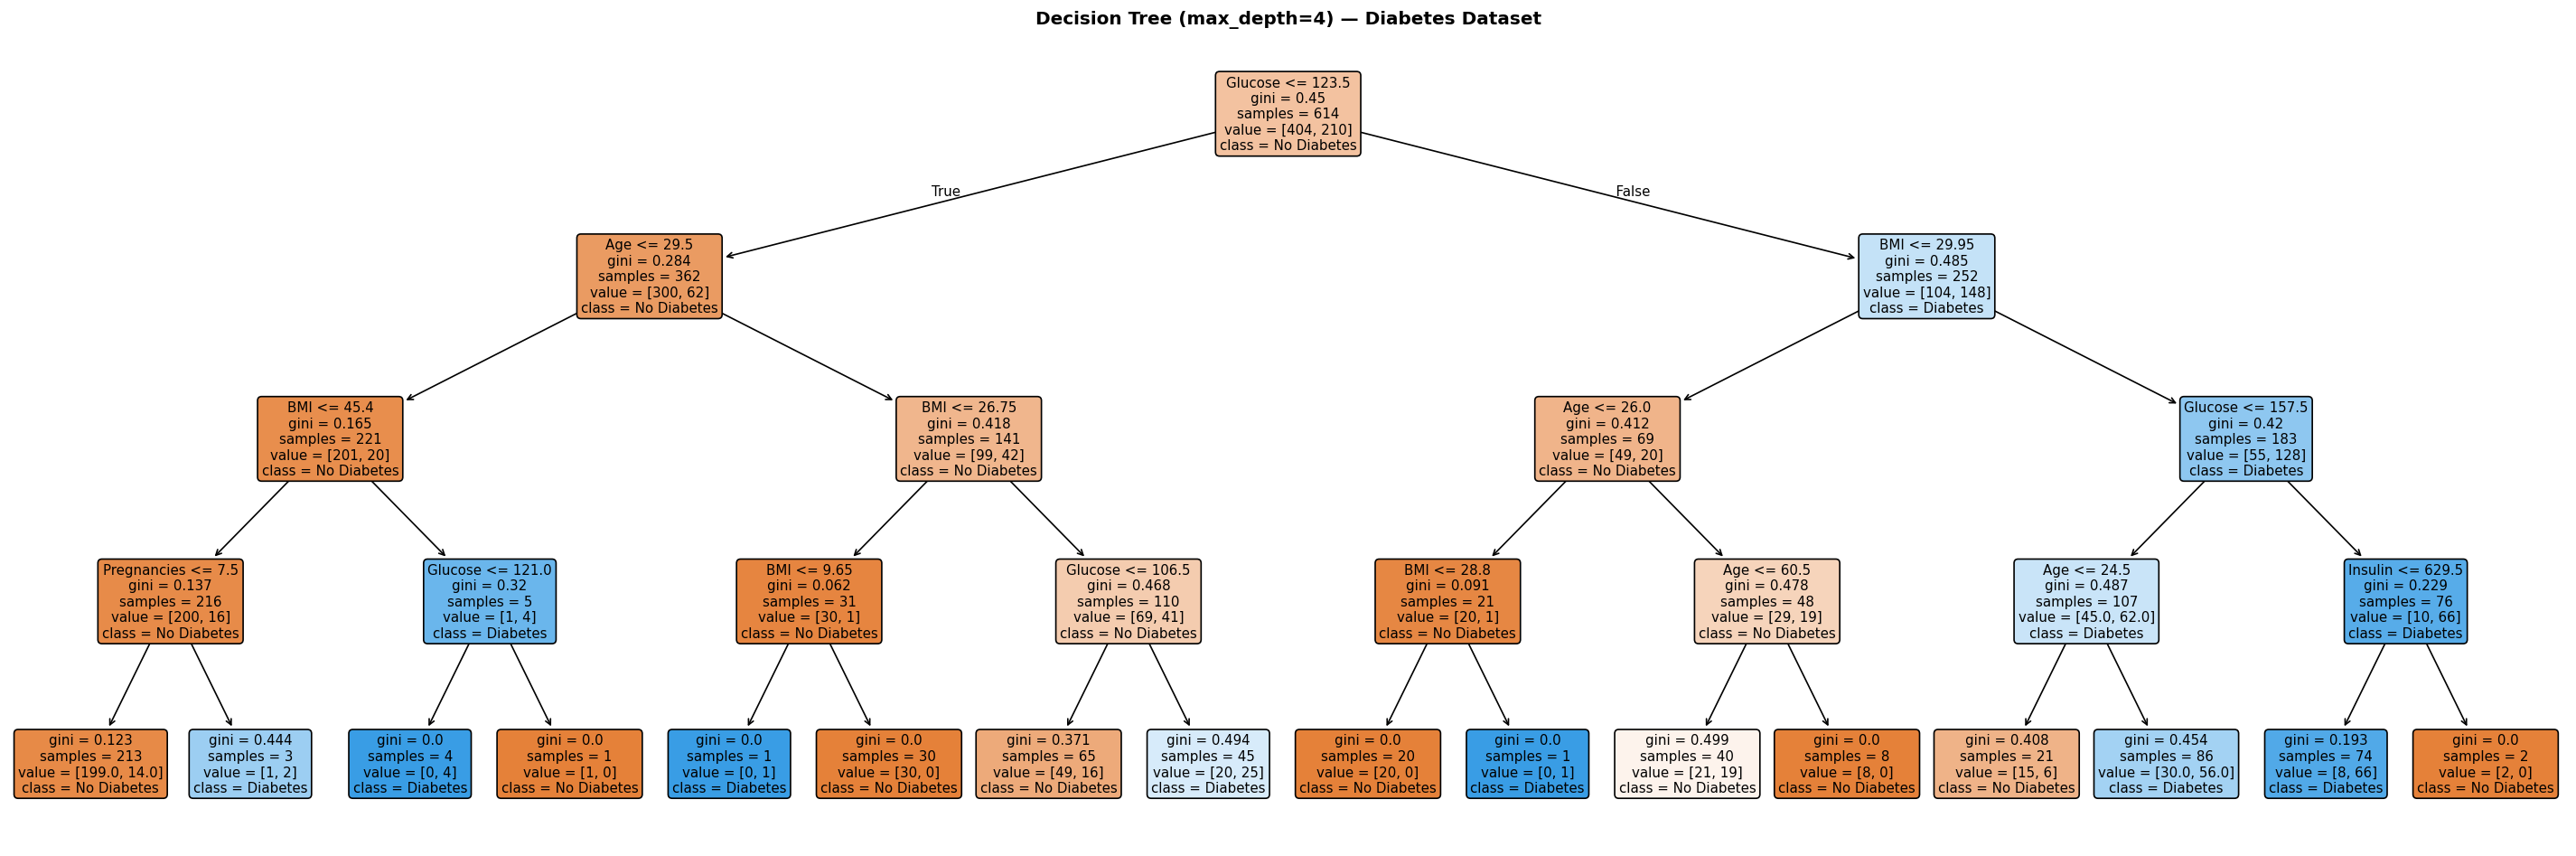

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

feature_names = list(data.drop(columns=["Outcome"]).columns)
class_names = ["No Diabetes", "Diabetes"]

# sklearn comparison at same max_depth
sklearn_tree = DecisionTreeClassifier(max_depth=4, random_state=SEED)
sklearn_tree.fit(X_train, y_train)
sk_pred = sklearn_tree.predict(X_test)

print(f"Our DT   — train: {tree.score(X_train, y_train):.3f}  test: {accuracy(y_test, y_pred):.3f}")
print(f"Sklearn  — train: {sklearn_tree.score(X_train, y_train):.3f}  test: {sklearn_tree.score(X_test, y_test):.3f}")

# Tree visualization
plt.figure(figsize=(24, 8))
plot_tree(sklearn_tree, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth=4) — Diabetes Dataset", fontweight="bold")
plt.tight_layout()
plt.show()


Wow! Our Scikit-learn's version produces very similar results. 

Our DT   — train: 0.814  test: 0.734
Sklearn  — train: 0.814  test: 0.734

Glucose and BMI dominate the splitting decisions, consistent with their known clinical relevance to diabetes, but small sample sizes at deeper nodes suggest the model may not generalize well to unseen patients.

## Using a Decision Tree to Predict Noise/Silence in Guitar Sets

The dataset is the canonical **GuitarSet subset** — 10 tracks (2 per genre: BN, Funk, Jazz, Rock, SS; randomised players, seed=42), all 6 strings, all frames. It is stored as a compressed CSV on GitHub Releases and downloaded automatically on first use, then cached at `~/.cache/rice_ml/`.

For the Decision Tree we use **string 0 (low E)** only and a **binary voiced/silent label**:

| Column | Description |
|--------|-------------|
| `rms` | RMS energy — overall loudness |
| `zcr` | Zero-crossing rate — noisiness |
| `centroid` | Spectral centroid — "brightness" |
| `bandwidth` | Spread around centroid |
| `rolloff` | Frequency below which 85% of energy lies |
| `mfcc_1`–`mfcc_13` | timbre |
| `midi_label` | 0 = silent, non-zero = MIDI note being played |

Label construction: any frame where `midi_label != 0` is **voiced** (1); all others are **silent** (0).

In [3]:
df_guitar = load_guitarset()

df_s0 = df_guitar[df_guitar["string_idx"] == 0].copy()
df_s0["voiced"] = (df_s0["midi_label"] != 0).astype(int)

X_g = df_s0[FEATURE_COLS].values
y_g = df_s0["voiced"].values

print(f"Frames : {len(df_s0):,}")
print(f"Silent : {(y_g == 0).sum():,}  ({(y_g == 0).mean():.1%})")
print(f"Voiced : {(y_g == 1).sum():,}  ({(y_g == 1).mean():.1%})")

Loading from cache: C:\Users\joshh\.cache\rice_ml\guitarset_subset.csv.gz
Frames : 20,762
Silent : 18,714  (90.1%)
Voiced : 2,048  (9.9%)


In [18]:
rng_sub = np.random.default_rng(SEED)
n = min(50_000, len(X_g))
idx = rng_sub.choice(len(X_g), size=n, replace=False)
X_g_sub, y_g_sub = X_g[idx], y_g[idx]
print(f"Using {n:,} frames")


Using 20,762 frames


In [23]:
X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=SEED, stratify=y_g
)

gt = DecisionTree(max_depth=2, criterion="gini")
gt.fit(X_g_train, y_g_train)

y_g_pred = gt.predict(X_g_test)
print(f"Train accuracy: {gt.score(X_g_train, y_g_train):.3f}")
print(f"Test accuracy:  {accuracy(y_g_test, y_g_pred):.3f}")


KeyboardInterrupt: 

In [ ]:
cm_g = np.array([
    [((y_g_test==0) & (y_g_pred==0)).sum(), ((y_g_test==0) & (y_g_pred==1)).sum()],
    [((y_g_test==1) & (y_g_pred==0)).sum(), ((y_g_test==1) & (y_g_pred==1)).sum()],
])
class_names_g = ["Silent", "Voiced"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_g, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(2)); ax.set_xticklabels(class_names_g)
ax.set_yticks(range(2)); ax.set_yticklabels(class_names_g)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — GuitarSet Voiced/Silent", fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_g[i, j]:,}", ha="center", va="center",
                color="white" if cm_g[i, j] > cm_g.max() / 2 else "black")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier as SklearnDT, plot_tree

sk_gt = SklearnDT(max_depth=6, criterion="gini", random_state=SEED)
sk_gt.fit(X_g_train, y_g_train)
sk_g_pred = sk_gt.predict(X_g_test)

print(f"Our DT  — train: {gt.score(X_g_train, y_g_train):.3f}  test: {accuracy(y_g_test, y_g_pred):.3f}")
print(f"Sklearn — train: {sk_gt.score(X_g_train, y_g_train):.3f}  test: {sk_gt.score(X_g_test, y_g_test):.3f}")

plt.figure(figsize=(28, 8))
plot_tree(sk_gt, max_depth=3, feature_names=FEATURE_NAMES,
          class_names=class_names_g, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (max_depth=6, first 3 levels shown) — GuitarSet Voiced/Silent", fontweight="bold")
plt.tight_layout()
plt.show()
